# Modeling exploration

Use this notebook to iterate on feature engineering and model behavior locally without Strava API calls.

## Setup

Run once from repo root:
```bash
pip install -r requirements-dev.txt
python -m ipykernel install --user --name train-tomorrow
```

To use live data, set `USE_LIVE_DATA = True` in the next cell. Requires a repo-root `.env` with `STRAVA_CLIENT_ID`, `STRAVA_CLIENT_SECRET`, `STRAVA_REFRESH_TOKEN`, and optionally `FORECAST_LAT`/`FORECAST_LON`.

In [1]:
import os
import tempfile
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
from dotenv import load_dotenv
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay

from blurb import generate_blurb, summarize_top_contributors, generate_gemini_prompt, generate_blurb_llm
from features import FEATURE_COLUMNS, prepare_datasets
from model import evaluate_models, feature_contributions, predict_tomorrow, train_and_save_models, walk_forward_evaluate
from strava_client import fetch_activities_dataframe, out_of_range_dates
from weather_client import DEFAULT_LAT, DEFAULT_LON, fetch_historical_weather, fetch_tomorrow_forecast

load_dotenv(Path.cwd().parent / ".env")  # repo root .env when running from scripts/


True

In [2]:
USE_LIVE_DATA = True  # set True to pull real Strava activities + Open-Meteo forecast via .env secrets


def synthetic_activities(days: int = 120) -> pd.DataFrame:
    start = pd.Timestamp.today().normalize() - pd.to_timedelta(days, unit='D')
    rows = []
    for i in range(days):
        day = start + pd.to_timedelta(i, unit='D')
        if i % 2 == 0 or i % 5 == 0:
            rows.append({
                'date': day.date().isoformat(),
                'type': 'Run',
                'moving_time': 1800 + i * 12,
                'distance': 4500 + i * 35,
                'relative_effort': float(20 + (i % 14) * 3),
                'average_watts': float('nan'),
            })
    return pd.DataFrame(rows)

if USE_LIVE_DATA:
    activities = fetch_activities_dataframe(days_back=365*2)
    weather = fetch_tomorrow_forecast()
    activity_dates = pd.to_datetime(activities['date'], errors='coerce').dt.date.dropna()
    historical_weather = (
        fetch_historical_weather(activity_dates.min(), activity_dates.max())
        if not activity_dates.empty
        else None
    )
    if historical_weather is not None:
        home_lat = float(os.getenv('FORECAST_LAT', DEFAULT_LAT))
        home_lon = float(os.getenv('FORECAST_LON', DEFAULT_LON))
        stale_dates = out_of_range_dates(activities, home_lat, home_lon)
        historical_weather = historical_weather.drop(index=list(stale_dates), errors='ignore')
else:
    activities = synthetic_activities()
    weather = {
        'temp_high': 18.0,
        'temp_low': 11.0,
        'precip_probability': 25.0,
        'wind_speed': 10.0,
    }
    historical_weather = None

prepared = prepare_datasets(activities=activities, tomorrow_weather=weather, historical_weather=historical_weather)
prepared.historical[['as_of_date', 'target_date'] + FEATURE_COLUMNS + ['will_train_tomorrow']].tail(2)


Fetched 726 activities from Strava. Used 4 pages to get 730 days


,as_of_date,target_date,acute_load_7,chronic_load_28,atl_ctl_ratio,days_since_last_hard,streak_length,trained_today,trained_hard_today,trained_days_2,...,month_train_rate,day_of_week,month,season,days_since_last_long_ride,forecast_temp_high,forecast_temp_low,forecast_precip_probability,forecast_wind_speed,will_train_tomorrow
726,2026-09-19,2026-09-20,40.731072,26.850299,1.516969,1,0,0,0,1.0,...,0.526316,6,9,3,1,20.5,8.9,0.0,8.0,0
727,2026-09-20,2026-09-21,30.548304,24.998554,1.222003,2,0,0,0,0.0,...,0.517241,0,9,3,2,19.7,9.0,0.0,9.8,1


In [3]:
prepared.historical.will_train_tomorrow.mean()

np.float64(0.5178571428571429)

In [4]:
with tempfile.TemporaryDirectory() as tmpdir:
    models = train_and_save_models(prepared.historical, Path(tmpdir))
    prediction = predict_tomorrow(models, prepared.tomorrow_features)
    contributions = feature_contributions(models.classifier, prepared.tomorrow_features)

prediction

[model] classifier_accuracy=0.651 (baseline=0.699)
[model] classifier_auc=0.664
[model] classifier_precision=0.774 recall=0.706 f1=0.738
[model] regressor_mae=34.373


{'will_train': True,
 'probability': 0.7799689769744873,
 'predicted_effort': 43.58419418334961}

## Model analysis

Confusion matrix / ROC for the classifier, predicted-vs-actual for the regressor, and feature importances — all computed on the same held-out time-based test split used during training.

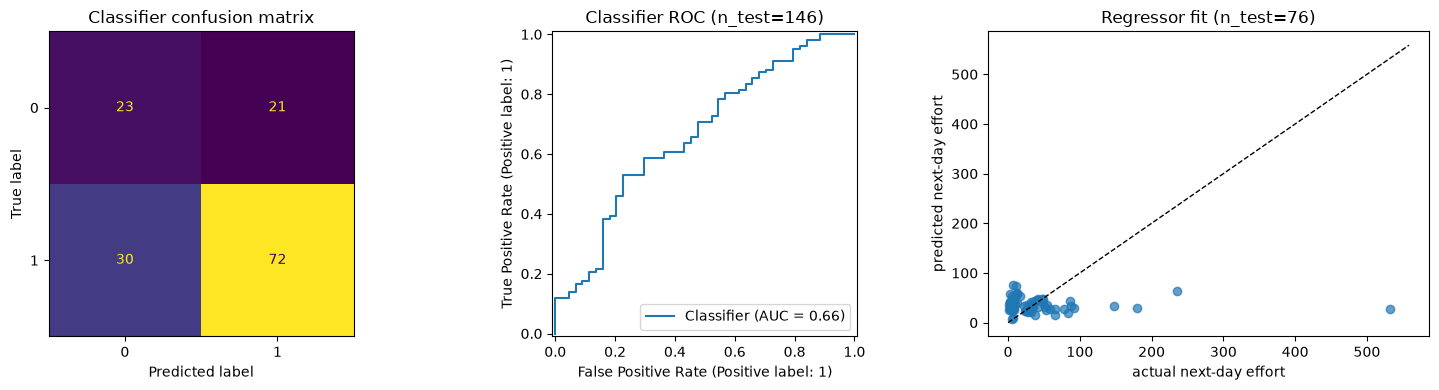

In [5]:
eval_results = evaluate_models(models, prepared.historical)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ConfusionMatrixDisplay.from_predictions(
    eval_results['y_test'], (eval_results['probs'] >= 0.5).astype(int), ax=axes[0], colorbar=False
)
axes[0].set_title('Classifier confusion matrix')

RocCurveDisplay.from_predictions(eval_results['y_test'], eval_results['probs'], ax=axes[1])
axes[1].set_title(f"Classifier ROC (n_test={len(eval_results['y_test'])})")

axes[2].scatter(eval_results['reg_true'], eval_results['reg_pred'], alpha=0.7)
lims = [0, max(eval_results['reg_true'].max(), eval_results['reg_pred'].max(), 1) * 1.05]
axes[2].plot(lims, lims, 'k--', linewidth=1)
axes[2].set_xlabel('actual next-day effort')
axes[2].set_ylabel('predicted next-day effort')
axes[2].set_title(f"Regressor fit (n_test={len(eval_results['reg_true'])})")

plt.tight_layout()
plt.show()

In [6]:
importance_df = pd.DataFrame({
    'feature': FEATURE_COLUMNS,
    'classifier_importance': models.classifier.feature_importances_,
    'regressor_importance': models.regressor.feature_importances_,
}).sort_values('classifier_importance', ascending=False).reset_index(drop=True)

importance_df

,feature,classifier_importance,regressor_importance
0,month,0.074085,0.077466
1,trained_today,0.072105,0.060465
2,trained_days_30,0.061627,0.048533
3,days_since_last_hard,0.061557,0.038337
4,forecast_precip_probability,0.055006,0.076550
5,day_of_week,0.051681,0.035809
6,trained_days_7,0.051521,0.056594
7,month_train_rate,0.046557,0.042441
8,forecast_wind_speed,0.045475,0.039456
9,moving_time_chronic_28,0.041576,0.031353


## Is 0.65 AUC stable, or one unlucky test window?

A single 80/20 holdout tests one fixed slice of time. This retrains on an expanding window and re-tests fold by fold, so you can see whether the classifier's AUC/accuracy is consistent across different periods or swings wildly (which would point to a hard-to-model window rather than a broken model).

In [7]:
folds = walk_forward_evaluate(prepared.historical, n_folds=5)
folds

,fold,n_train,n_test,positive_rate,auc,accuracy,baseline_accuracy
0,0,364,72,0.416667,0.619841,0.597222,0.583333
1,1,436,73,0.561644,0.593750,0.465753,0.561644
2,2,509,73,0.712329,0.542125,0.602740,0.712329
3,3,582,73,0.726027,0.640566,0.657534,0.726027
4,4,655,73,0.671233,0.698980,0.684932,0.671233


In [ ]:
top_contributors = summarize_top_contributors(contributions, top_n=11)
blurb = generate_blurb(
    will_train=prediction['will_train'],
    probability=prediction['probability'],
    predicted_effort=prediction['predicted_effort'],
    top_contributors=top_contributors,
)
llm_blurb = generate_blurb_llm(
    will_train=prediction['will_train'],
    probability=prediction['probability'],
    predicted_effort=prediction['predicted_effort'],
    top_contributors=top_contributors,
    fallback_blurb=blurb,
)

pd.DataFrame(top_contributors)
# print(blurb)
print(llm_blurb)

Tomorrow trends green at 78%. your training frequency over the past month is on your side; how hard today's session was is the speed bump. Think ~44 relative-effort points.
**The Verdict:** 
Clear your schedule—you’re training tomorrow. The model gives you a **78% chance** of lacing up, expecting a modest, easy-ish session around **43.6 relative-effort units**. 

**Why you're getting out the door:**
* **You’re a creature of habit:** Your relentless consistency over the past month (your top driver) and your predictable day-of-week routine mean your brain is basically on autopilot. 
* **The engine is primed:** Your solid fitness base and recent load are pulling their weight to keep you moving.

**What you’ll try to use as an excuse:**
* **"Today was hard":** Today’s grueling effort is making your legs act dramatic and dragging down your motivation. 
* **A little wind:** The breeze in the forecast is trying to give you a reason to stay on the couch. 

**Bottom line?** Your habits are offi

In [14]:
test_output = {
    "date": str(prepared.tomorrow_features.iloc[0]["target_date"]),
    "will_train": bool(prediction["will_train"]),
    "probability": round(float(prediction["probability"]), 4),
    "predicted_effort": (
        round(float(prediction["predicted_effort"]), 2)
        if prediction["predicted_effort"] is not None
        else None
    ),
    "top_contributors": top_contributors,
    "blurb": llm_blurb,
}